<a href="https://colab.research.google.com/github/geeta7777chavan-boop/python-practicals/blob/main/practical_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Geeta Santosh Chavan

Roll no./ Branch/ Class : AIDS-SY-A-66

# **Practical No. 9**

### **Aim:**

Building a Simple Data Science Pipeline: Integrate all learned techniques from previous labs into a complete workflow.

## **Theory**


**1. What is a Data Science Pipeline? Explain its key stages with examples.**

A Data Science Pipeline is a structured sequence of steps used to solve a data-related problem efficiently, starting from data collection to final model deployment.

It ensures that the entire process is organized, reproducible, and scalable.

Key Stages of a Data Science Pipeline:

**Data Collection :**
Gathering data from sources such as databases, APIs, CSV files, or sensors.
Example: Collecting e-scooter usage data from a city database.

**Data Cleaning :**
Handling missing values, removing duplicates, and fixing errors.
Example: Replacing missing mileage values with the average.

**Exploratory Data Analysis (EDA) :**
Understanding patterns, distributions, and relationships in data.
Example: Plotting histograms of speed or battery usage.

**Feature Engineering :**
Creating new meaningful features from existing data.
Example: Creating “battery efficiency” = distance / battery used.

**Feature Selection & Preprocessing :**
Selecting important features and applying encoding or scaling.
Example: Converting vehicle type into numeric form.

**Model Building :**
Applying machine learning algorithms.
Example: Using Linear Regression to predict emissions.

**Model Evaluation :**
Checking performance using metrics like accuracy, RMSE, etc.
Example: Comparing predicted vs actual emissions.

**Deployment :**
Making the model available for real-world use.
Example: Integrating the model into a mobile app.

**2. What is Exploratory Data Analysis (EDA)? How do univariate and bivariate analyses help in understanding the dataset?**

Exploratory Data Analysis (EDA) is the process of analyzing and summarizing datasets to understand their main characteristics before applying machine learning models.

It helps in detecting patterns, anomalies, and relationships.

Types of Analysis:

**Univariate Analysis (Single Variable):**
Analyzes one variable at a time.

Helps understand distribution, central tendency, and spread.
Tools: Histogram, Box Plot
Example: Distribution of vehicle speed.

**Bivariate Analysis (Two Variables)**:
Analyzes the relationship between two variables.

Helps identify correlation or dependency.
Tools: Scatter plot, Correlation matrix
Example: Relationship between speed and emissions.

Conclusion:
Univariate analysis helps understand individual features, while bivariate analysis helps understand relationships between variables.

**3. Differentiate between Label Encoding and One-Hot Encoding. When should each be used?**

| Feature    | Label Encoding                          | One-Hot Encoding                        |
| ---------- | --------------------------------------- | --------------------------------------- |
| Definition | Converts categories into numeric labels | Converts categories into binary columns |
| Example    | Red=0, Blue=1, Green=2                  | Red=[1,0,0], Blue=[0,1,0]               |
| Data Type  | Ordinal                                 | Nominal                                 |
| Meaning    | Implies order                           | No order implied                        |
| Risk       | Model may assume ranking                | No such issue                           |


When to Use:

Label Encoding: When categories have a natural order

Example: Low < Medium < High

One-Hot Encoding: When categories are independent

Example: Colors, cities, vehicle types

**4. Why is feature scaling required? Compare normalization and standardization.**

Feature Scaling is used to bring all features to a similar scale so that no feature dominates others during model training.

It is especially important for algorithms like KNN, SVM, and Gradient Descent.

Types of Feature Scaling:

Normalization (Min-Max Scaling)

Scales data between 0 and 1

Formula:

$$
X' = \frac{X - X_{min}}{X_{max} - X_{min}}
$$




*   Used when data does not follow a normal distribution
*   Sensitive to outliers

Standardization (Z-score Scaling) :
$$
Z = \frac{X - \mu}{\sigma}
$$


*   Centers data around mean (0) with standard deviation 1

*   Works well with normally distributed data
*  Less affected by outliers



**Comparison:**
| Feature  | Normalization   | Standardization    |
| -------- | --------------- | ------------------ |
| Range    | 0 to 1          | Mean = 0, Std = 1  |
| Outliers | Sensitive       | Less sensitive     |
| Use Case | Neural Networks | Most ML algorithms |


**5. What is Feature Engineering? Explain how creating new features can improve model performance.**

Feature Engineering is the process of creating new input features from existing data to improve model performance.

It helps the model better understand hidden patterns in the data.


Examples:

Creating Age from Date of Birth

Creating Total Price = Quantity × Price

Extracting Day/Month from a date

Why It Improves Performance:

Provides more meaningful inputs

Reduces noise and irrelevant data

Helps models capture complex relationships

Increases prediction accuracy

Example:

Instead of using “distance” and “battery used” separately, creating a feature like:

Efficiency = Distance / Battery Used

gives better insights for prediction.

# **Implementation**

**Step 1: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

**Step 2: Data Ingestion (Create Sample Dataset)**

In [ ]:
data = {
    "Distance": [5, 10, 15, 20, 25],
    "Battery_Used": [1, 2, 3, 4, 5],
    "Speed": [25, 30, 35, 40, 45]
}

df = pd.DataFrame(data)
print(df)

   Distance  Battery_Used  Speed
0         5             1     25
1        10             2     30
2        15             3     35
3        20             4     40
4        25             5     45


**Step 3: Data Cleaning**

In [ ]:
# Check missing values
print(df.isnull().sum())

# No missing values in this dataset

Distance        0
Battery_Used    0
Speed           0
dtype: int64


**Step 4: Data Wrangling (Feature Engineering)**

In [ ]:
# Create new feature: Efficiency
df["Efficiency"] = df["Distance"] / df["Battery_Used"]

print(df)

   Distance  Battery_Used  Speed  Efficiency
0         5             1     25         5.0
1        10             2     30         5.0
2        15             3     35         5.0
3        20             4     40         5.0
4        25             5     45         5.0


**Step 5: Numerical Computation (NumPy)**

In [ ]:
mean_speed = np.mean(df["Speed"])
print("Mean Speed:", mean_speed)

Mean Speed: 35.0


**Step 6: Data Visualization**

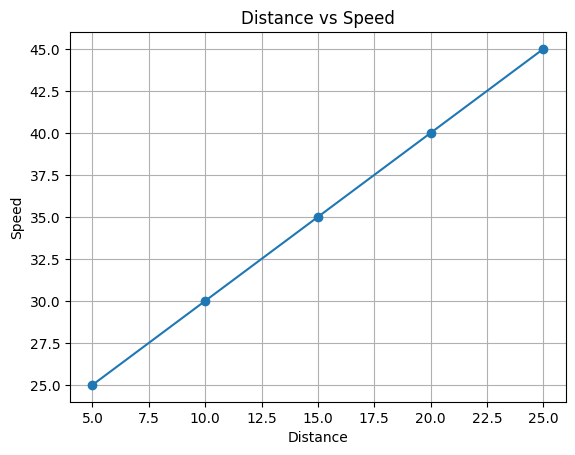

In [ ]:
plt.figure()

plt.plot(df["Distance"], df["Speed"], marker='o')

plt.xlabel("Distance")
plt.ylabel("Speed")
plt.title("Distance vs Speed")

plt.grid()

plt.show()

**Step 7: Feature Scaling (Normalization)**

In [ ]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

print("Scaled Data:\n", df_scaled)

Scaled Data:
 [[0.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.  ]
 [0.5  0.5  0.5  0.  ]
 [0.75 0.75 0.75 0.  ]
 [1.   1.   1.   0.  ]]


**Step 8: Model Building (Linear Regression)**

In [ ]:
X = df[["Distance"]]
y = df["Speed"]

model = LinearRegression()
model.fit(X, y)

prediction = model.predict([[30]])
print("Predicted Speed for Distance 30:", prediction[0])

Predicted Speed for Distance 30: 50.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Conclusion**

A Data Science Pipeline integrates all steps such as data collection, preprocessing, analysis, feature engineering, and modeling into a structured workflow. Proper use of EDA, encoding, scaling, and feature engineering significantly improves the efficiency and accuracy of machine learning models.